# Programación lineal y derivadas aplicadas a la gestión organizacional

Cuaderno introductorio para estudiantes que recién empiezan en análisis de datos y gestión organizacional.

Vamos a ver 3 casos prácticos:

1. **Economía marginal y programación lineal económica**
2. **Derivadas y programación lineal en gestión de datos**
3. **Caso de fútbol: derivadas y programación lineal**

No se usan diccionarios ni estructuras avanzadas. Todo el código está pensado para leerse de arriba hacia abajo, celda por celda.

Ejecutá las celdas en orden (Entorno de ejecución > Ejecutar todas, o `Shift + Enter` celda por celda).


## Librerías que vamos a usar

- **pandas**: para armar y mostrar tablas de datos.
- **numpy**: para cálculos numéricos y generar puntos para los gráficos.
- **matplotlib**: para graficar.
- **sympy**: para calcular derivadas de forma simbólica.
- **scipy.optimize.linprog**: para resolver problemas de programación lineal.

Todas vienen preinstaladas en Google Colab, así que no hace falta instalar nada, solo importar.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from scipy.optimize import linprog

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


---
## Caso 1: Economía marginal y programación lineal económica

**Historia:** Una carpintería fabrica **sillas** y **mesas**.

- Cada silla deja una ganancia de **$50** y requiere **6 horas de carpintería** y **1 hora de pintura**.
- Cada mesa deja una ganancia de **$40** y requiere **4 horas de carpintería** y **2 horas de pintura**.
- Por semana se dispone de **24 horas de carpintería** y **6 horas de pintura**.

**Pregunta:** ¿cuántas sillas y mesas conviene producir para maximizar la ganancia semanal?

Esto es un problema de **programación lineal**: maximizar una función (la ganancia) sujeta a restricciones de recursos.


In [2]:
# Armamos una tabla simple con los datos del problema (sin diccionarios)
productos = pd.DataFrame()
productos["producto"] = ["Silla", "Mesa"]
productos["ganancia_unidad"] = [50, 40]
productos["horas_carpinteria"] = [6, 4]
productos["horas_pintura"] = [1, 2]

productos


,producto,ganancia_unidad,horas_carpinteria,horas_pintura
0,Silla,50,6,1
1,Mesa,40,4,2


In [3]:
# scipy.optimize.linprog siempre MINIMIZA, por eso usamos la ganancia en negativo
# (minimizar -ganancia equivale a maximizar la ganancia)
c = [-50, -40]  # coeficientes de la funcion objetivo (Silla, Mesa)

# Restricciones de recursos: A_ub @ [sillas, mesas] <= b_ub
A_ub = [[6, 4],   # horas de carpinteria usadas
        [1, 2]]   # horas de pintura usadas
b_ub = [24, 6]    # horas disponibles

# Las cantidades producidas no pueden ser negativas
limite_sillas = (0, None)
limite_mesas = (0, None)

resultado = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=[limite_sillas, limite_mesas])

sillas = resultado.x[0]
mesas = resultado.x[1]
ganancia_maxima = -resultado.fun

print("Sillas a producir por semana:", round(sillas, 2))
print("Mesas a producir por semana:", round(mesas, 2))
print("Ganancia maxima semanal: $", round(ganancia_maxima, 2))


Sillas a producir por semana: 3.0
Mesas a producir por semana: 1.5
Ganancia maxima semanal: $ 210.0


### Análisis marginal: ¿cuánto vale una hora extra de un recurso?

En economía, el **beneficio marginal** de un recurso es cuánto aumenta la ganancia si se dispone de una unidad más de ese recurso (por ejemplo, una hora extra de carpintería).

Lo calculamos de forma simple: resolvemos el mismo problema con una hora extra y comparamos la ganancia.


In [4]:
# Volvemos a resolver el problema con 1 hora extra de carpinteria (24 -> 25)
b_extra = [25, 6]
resultado_extra = linprog(c, A_ub=A_ub, b_ub=b_extra, bounds=[limite_sillas, limite_mesas])
ganancia_extra = -resultado_extra.fun

beneficio_marginal_carpinteria = ganancia_extra - ganancia_maxima
print("Ganancia con 1 hora extra de carpinteria: $", round(ganancia_extra, 2))
print("Beneficio marginal de esa hora extra: $", round(beneficio_marginal_carpinteria, 2))


Ganancia con 1 hora extra de carpinteria: $ 217.5
Beneficio marginal de esa hora extra: $ 7.5


Ahora graficamos la **región factible** (las combinaciones de sillas y mesas que cumplen las dos restricciones) y marcamos el punto óptimo encontrado.

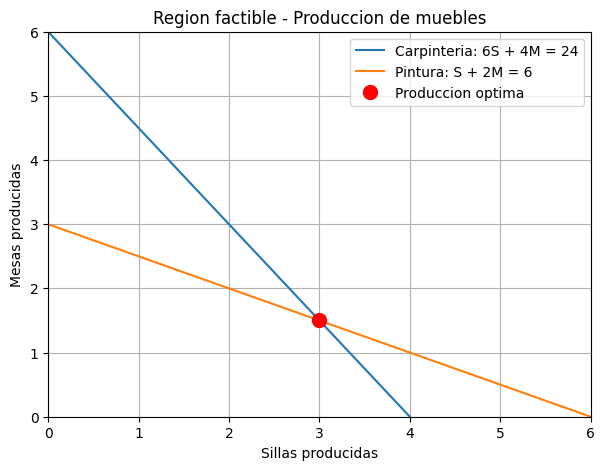

In [5]:
sillas_grafico = np.linspace(0, 6, 100)

# Despejamos "mesas" de cada restriccion para poder graficarla como una recta
recta_carpinteria = (24 - 6 * sillas_grafico) / 4
recta_pintura = (6 - sillas_grafico) / 2

plt.figure(figsize=(7, 5))
plt.plot(sillas_grafico, recta_carpinteria, label="Carpinteria: 6S + 4M = 24")
plt.plot(sillas_grafico, recta_pintura, label="Pintura: S + 2M = 6")
plt.plot(sillas, mesas, "ro", markersize=10, label="Produccion optima")

plt.xlabel("Sillas producidas")
plt.ylabel("Mesas producidas")
plt.title("Region factible - Produccion de muebles")
plt.xlim(0, 6)
plt.ylim(0, 6)
plt.legend()
plt.grid(True)
plt.show()


---
## Caso 2: Derivadas y programación lineal en gestión de datos

### Parte A: derivadas para minimizar un costo

**Historia:** un equipo de datos mide el **costo de procesamiento** según la cantidad de registros que procesa por hora (en miles). Si procesa muy pocos registros por hora, se desperdicia capacidad; si procesa demasiados, aumentan los errores y el costo de corregirlos.

El costo se modela con la función:

`costo(x) = x^2 - 40x + 500`

donde `x` es la cantidad de registros procesados por hora (en miles).

Para encontrar el mínimo de esta función usamos **derivadas**: el mínimo ocurre donde la derivada es igual a cero.


In [6]:
x = sp.symbols("x")
costo = x**2 - 40 * x + 500

derivada_costo = sp.diff(costo, x)
print("Funcion de costo:", costo)
print("Derivada del costo:", derivada_costo)


Funcion de costo: x**2 - 40*x + 500
Derivada del costo: 2*x - 40


In [7]:
# El minimo se da donde la derivada es 0
punto_critico = sp.solve(derivada_costo, x)
registros_optimos = float(punto_critico[0])
costo_minimo = float(costo.subs(x, registros_optimos))

print("Registros por hora que minimizan el costo (miles):", registros_optimos)
print("Costo minimo:", round(costo_minimo, 2))


Registros por hora que minimizan el costo (miles): 20.0
Costo minimo: 100.0


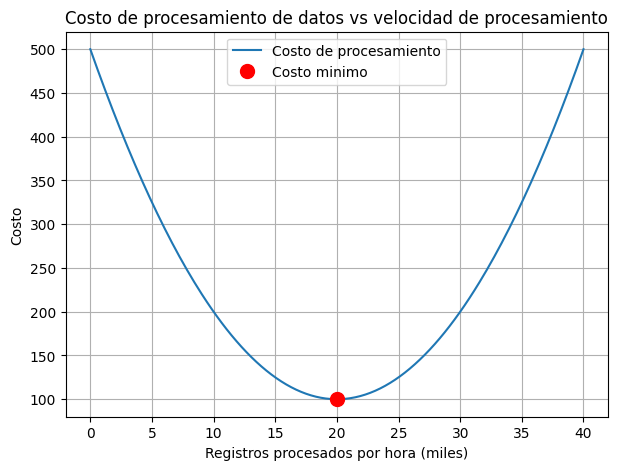

In [8]:
x_grafico = np.linspace(0, 40, 200)
costo_grafico = x_grafico**2 - 40 * x_grafico + 500

plt.figure(figsize=(7, 5))
plt.plot(x_grafico, costo_grafico, label="Costo de procesamiento")
plt.plot(registros_optimos, costo_minimo, "ro", markersize=10, label="Costo minimo")

plt.xlabel("Registros procesados por hora (miles)")
plt.ylabel("Costo")
plt.title("Costo de procesamiento de datos vs velocidad de procesamiento")
plt.legend()
plt.grid(True)
plt.show()


### Parte B: programación lineal para repartir horas de trabajo

**Historia:** el mismo equipo tiene dos tipos de tareas: **limpieza de datos** y **análisis de datos**.

- Cada tarea de limpieza toma **2 horas** y genera **5 puntos de valor** para la organización.
- Cada tarea de análisis toma **4 horas** y genera **9 puntos de valor**.
- El equipo dispone de **40 horas** por semana y puede realizar como máximo **15 tareas** en total.

**Pregunta:** ¿cuántas tareas de cada tipo conviene hacer para maximizar el valor generado?


In [9]:
tareas = pd.DataFrame()
tareas["tarea"] = ["Limpieza", "Analisis"]
tareas["horas_por_tarea"] = [2, 4]
tareas["valor_por_tarea"] = [5, 9]

tareas


,tarea,horas_por_tarea,valor_por_tarea
0,Limpieza,2,5
1,Analisis,4,9


In [10]:
c2 = [-5, -9]  # minimizamos el negativo del valor para maximizarlo

A2_ub = [[2, 4],   # horas usadas
         [1, 1]]   # cantidad de tareas totales
b2_ub = [40, 15]   # horas disponibles y maximo de tareas

limite_tareas = (0, None)

resultado2 = linprog(c2, A_ub=A2_ub, b_ub=b2_ub, bounds=[limite_tareas, limite_tareas])

tareas_limpieza = resultado2.x[0]
tareas_analisis = resultado2.x[1]
valor_maximo = -resultado2.fun

print("Tareas de limpieza a realizar:", round(tareas_limpieza, 2))
print("Tareas de analisis a realizar:", round(tareas_analisis, 2))
print("Valor maximo generado:", round(valor_maximo, 2))


Tareas de limpieza a realizar: 10.0
Tareas de analisis a realizar: 5.0
Valor maximo generado: 95.0


---
## Caso 3: Fútbol — derivadas y programación lineal

### Parte A: un pequeño dataset de jugadores

Armamos un dataset simple con pandas para practicar estadística descriptiva básica antes de entrar en optimización.


In [11]:
jugadores = pd.DataFrame()
jugadores["jugador"] = ["Messi", "Mbappe", "Haaland", "Pedri", "Modric"]
jugadores["goles"] = [12, 15, 18, 4, 3]
jugadores["asistencias"] = [10, 6, 3, 8, 9]

# Puntaje fantasy simple: 4 puntos por gol, 3 puntos por asistencia
jugadores["puntos"] = jugadores["goles"] * 4 + jugadores["asistencias"] * 3

jugadores


,jugador,goles,asistencias,puntos
0,Messi,12,10,78
1,Mbappe,15,6,78
2,Haaland,18,3,81
3,Pedri,4,8,40
4,Modric,3,9,39


In [12]:
print("Promedio de goles del equipo:", jugadores["goles"].mean())
print("Total de asistencias del equipo:", jugadores["asistencias"].sum())

mejor_jugador = jugadores.sort_values("puntos", ascending=False).head(1)
print("\nJugador con mas puntos:")
mejor_jugador


Promedio de goles del equipo: 10.4
Total de asistencias del equipo: 36

Jugador con mas puntos:


,jugador,goles,asistencias,puntos
2,Haaland,18,3,81


### Parte B: derivadas para encontrar el entrenamiento óptimo

**Historia:** para un jugador, la cantidad de goles esperados en la temporada depende de las **horas de entrenamiento por día**. Entrenar poco da pocos goles, pero entrenar demasiado cansa al jugador y el rendimiento empieza a bajar.

Se modela con la función:

`goles(h) = -0.5*h^2 + 6h`

donde `h` son las horas de entrenamiento por día.

Buscamos el máximo de esta función usando la derivada.


In [13]:
h = sp.symbols("h")
goles = -0.5 * h**2 + 6 * h

derivada_goles = sp.diff(goles, h)
print("Funcion de goles:", goles)
print("Derivada de los goles respecto a las horas:", derivada_goles)


Funcion de goles: -0.5*h**2 + 6*h
Derivada de los goles respecto a las horas: 6 - 1.0*h


In [14]:
horas_optimas = sp.solve(derivada_goles, h)
horas_optimas = float(horas_optimas[0])
goles_maximos = float(goles.subs(h, horas_optimas))

print("Horas de entrenamiento optimas por dia:", horas_optimas)
print("Goles esperados en la temporada:", round(goles_maximos, 2))


Horas de entrenamiento optimas por dia: 6.0
Goles esperados en la temporada: 18.0


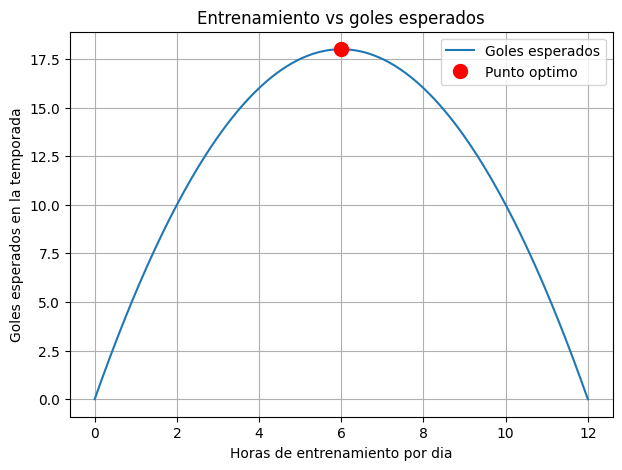

In [15]:
h_grafico = np.linspace(0, 12, 200)
goles_grafico = -0.5 * h_grafico**2 + 6 * h_grafico

plt.figure(figsize=(7, 5))
plt.plot(h_grafico, goles_grafico, label="Goles esperados")
plt.plot(horas_optimas, goles_maximos, "ro", markersize=10, label="Punto optimo")

plt.xlabel("Horas de entrenamiento por dia")
plt.ylabel("Goles esperados en la temporada")
plt.title("Entrenamiento vs goles esperados")
plt.legend()
plt.grid(True)
plt.show()


### Parte C: programación lineal para repartir las horas de entrenamiento del equipo

**Historia:** el cuerpo técnico reparte las horas semanales de entrenamiento entre **entrenamiento de ataque** y **entrenamiento de defensa**.

- Cada hora de entrenamiento de ataque suma **8 puntos** al puntaje del equipo.
- Cada hora de entrenamiento de defensa suma **6 puntos** al puntaje del equipo.
- El equipo entrena un total de **20 horas por semana**.
- Por reglamento físico, ni el ataque ni la defensa pueden entrenar más de **12 horas** por semana cada uno.

**Pregunta:** ¿cómo repartir las 20 horas para maximizar el puntaje del equipo?


In [16]:
c3 = [-8, -6]  # minimizamos el negativo del puntaje para maximizarlo

A3_ub = [[1, 1]]  # horas totales de entrenamiento
b3_ub = [20]

limite_ataque = (0, 12)
limite_defensa = (0, 12)

resultado3 = linprog(c3, A_ub=A3_ub, b_ub=b3_ub, bounds=[limite_ataque, limite_defensa])

horas_ataque = resultado3.x[0]
horas_defensa = resultado3.x[1]
puntaje_maximo = -resultado3.fun

print("Horas de entrenamiento de ataque:", round(horas_ataque, 2))
print("Horas de entrenamiento de defensa:", round(horas_defensa, 2))
print("Puntaje maximo del equipo:", round(puntaje_maximo, 2))


Horas de entrenamiento de ataque: 12.0
Horas de entrenamiento de defensa: 8.0
Puntaje maximo del equipo: 144.0


---
## Resumen

| Caso | Derivadas | Programación lineal |
|---|---|---|
| 1. Economía marginal | — | Mezcla óptima de producción (sillas y mesas) |
| 2. Gestión de datos | Velocidad óptima de procesamiento | Reparto óptimo de horas entre tareas |
| 3. Fútbol | Horas óptimas de entrenamiento individual | Reparto óptimo de horas de entrenamiento del equipo |

**Ideas clave:**

- Las **derivadas** sirven para encontrar el punto máximo o mínimo de una función (por ejemplo, el menor costo o el mayor rendimiento).
- La **programación lineal** sirve para repartir recursos limitados (horas, dinero, materiales) de la mejor manera posible, respetando restricciones.
- Ambas herramientas son muy usadas en gestión organizacional para tomar mejores decisiones con datos.
